Klasyfikator: sieci neuronowe, drzewo regresyjne, regresje liniowe, nie-liniowe.

In [ ]:
import requests

url = "https://bdl.stat.gov.pl/api/v1/data/by-variable/3776?unit-level=2"
response = requests.get(url)
data = response.json()
print(data)

{'totalRecords': 16, 'links': {'first': 'https://bdl.stat.gov.pl/api/v1/data/by-variable/3776?unit-level=2&page=0&page-size=10', 'self': 'https://bdl.stat.gov.pl/api/v1/data/by-variable/3776?unit-level=2&page=0&page-size=10', 'next': 'https://bdl.stat.gov.pl/api/v1/data/by-variable/3776?unit-level=2&page=1&page-size=10', 'last': 'https://bdl.stat.gov.pl/api/v1/data/by-variable/3776?unit-level=2&page=1&page-size=10'}, 'variableId': 3776, 'measureUnitId': 26, 'aggregateId': 1, 'lastUpdate': None, 'results': [{'id': '011200000000', 'name': 'MAŁOPOLSKIE', 'values': [{'year': '1999', 'val': 3, 'attrId': 1}, {'year': '2000', 'val': 3, 'attrId': 1}, {'year': '2001', 'val': 9, 'attrId': 1}, {'year': '2002', 'val': 0, 'attrId': 0}, {'year': '2003', 'val': 1, 'attrId': 1}, {'year': '2004', 'val': 5, 'attrId': 1}, {'year': '2005', 'val': 6, 'attrId': 1}, {'year': '2006', 'val': 7, 'attrId': 1}, {'year': '2007', 'val': 1, 'attrId': 1}, {'year': '2008', 'val': 2, 'attrId': 1}, {'year': '2009', 'val

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/data/'
df = pd.read_csv(path + 'dane.csv', header='infer')

Mounted at /content/drive


In [ ]:
print('(liczba rekordów, liczba atrybutów) = ', df.shape)

(liczba rekordów, liczba atrybutów) =  (1994, 128)


In [ ]:
df = df.replace('?',np.nan)

In [ ]:
# komulny do usuniecia
count = 0
polowa = len(df)/2
for col_name in df.columns:
    if df[col_name].isnull().sum() >= polowa:
        print(f"{col_name} - {df[col_name].isnull().sum()}")
        count += 1

print(f"\n=========   {count}   =============")

county - 1174
community - 1177
LemasSwornFT - 1675
LemasSwFTPerPop - 1675
LemasSwFTFieldOps - 1675
LemasSwFTFieldPerPop - 1675
LemasTotalReq - 1675
LemasTotReqPerPop - 1675
PolicReqPerOffic - 1675
PolicPerPop - 1675
RacialMatchCommPol - 1675
PctPolicWhite - 1675
PctPolicBlack - 1675
PctPolicHisp - 1675
PctPolicAsian - 1675
PctPolicMinor - 1675
OfficAssgnDrugUnits - 1675
NumKindsDrugsSeiz - 1675
PolicAveOTWorked - 1675
PolicCars - 1675
PolicOperBudg - 1675
LemasPctPolicOnPatr - 1675
LemasGangUnitDeploy - 1675
PolicBudgPerPop - 1675

=========   24   =============


In [ ]:
df = df.loc[:, df.isnull().sum() < polowa]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Columns: 104 entries, state to ViolentCrimesPerPop
dtypes: float64(100), int64(2), object(2)
memory usage: 1.6+ MB


In [ ]:
for col_name in df.columns:
    if df[col_name].isnull().sum() > 0:
        print(f"{col_name} - {df[col_name].isnull().sum()}")

OtherPerCap - 1


In [ ]:
features = [
    "agePct12t29",
    "agePct65up",
    "pctUrban",
    "pctWPubAsst",
    "perCapInc",
    "PctPopUnderPov",
    "PctNotHSGrad",
    "PctBSorMore",
    "PctUnemployed",
    "PctKids2Par",
    "PctIlleg",
    "PctImmigRec5",
    "PctNotSpeakEnglWell",
    "PctPersOwnOccup",
    "PctPersDenseHous",
    "PctVacantBoarded",
    "PctWOFullPlumb",
    "OwnOccMedVal",
    "MedRentPctHousInc",
    "NumStreet",
    "PopDens"
]

In [ ]:
target = "ViolentCrimesPerPop"

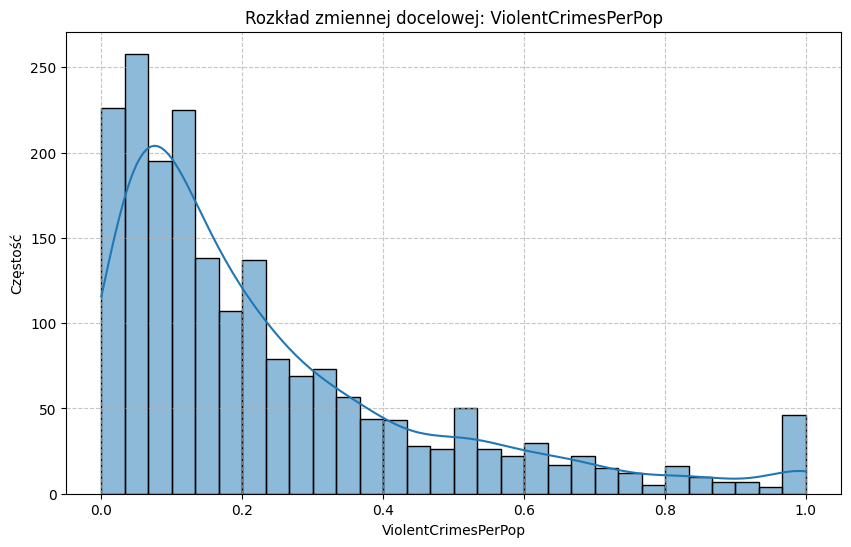

In [ ]:
y = df[target]

plt.figure(figsize=(10, 6))
sns.histplot(y, kde=True, bins=30)
plt.title('Rozkład zmiennej docelowej: ViolentCrimesPerPop')
plt.xlabel('ViolentCrimesPerPop')
plt.ylabel('Częstość')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
X = df[features]
y = df[target]

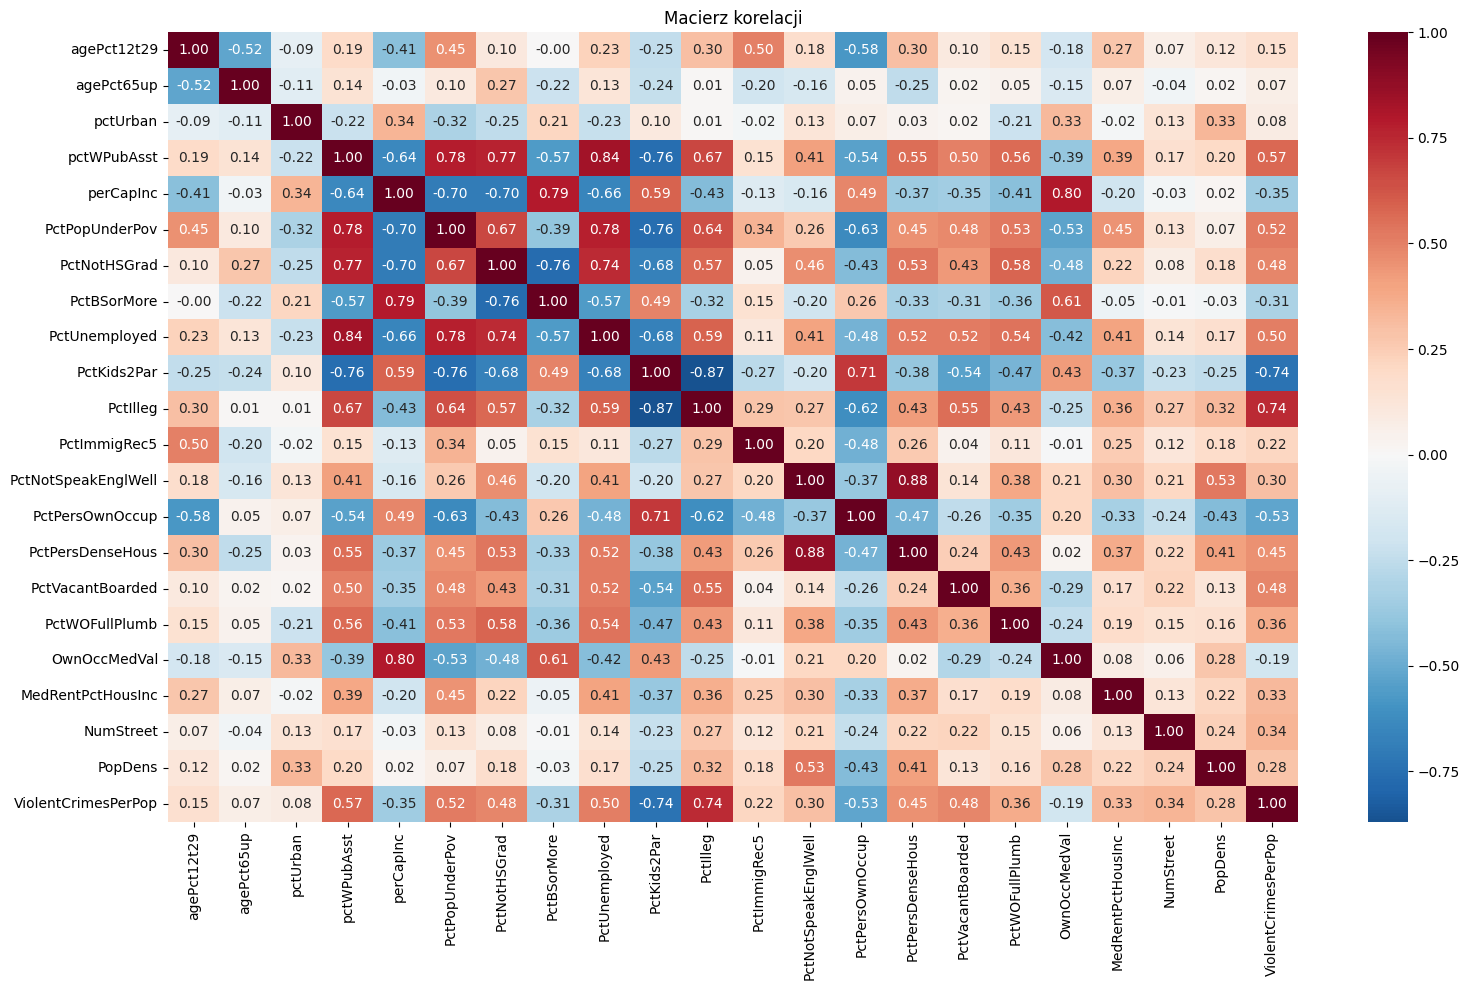

In [ ]:
df_corr = df[features + [target]]

corr_matrix = df_corr.corr()

plt.figure(figsize=(16, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0
)

plt.title("Macierz korelacji")
plt.tight_layout()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# Regresja liniowa

In [ ]:
#Linear Regression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)


print(f"MAE: {mae_lr:.4f}")
print(f"R2 Score: {r2_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"MSE: {mse_lr:.4f}")

MAE: 0.0912
R2 Score: 0.6545
RMSE: 0.1296
MSE: 0.0168


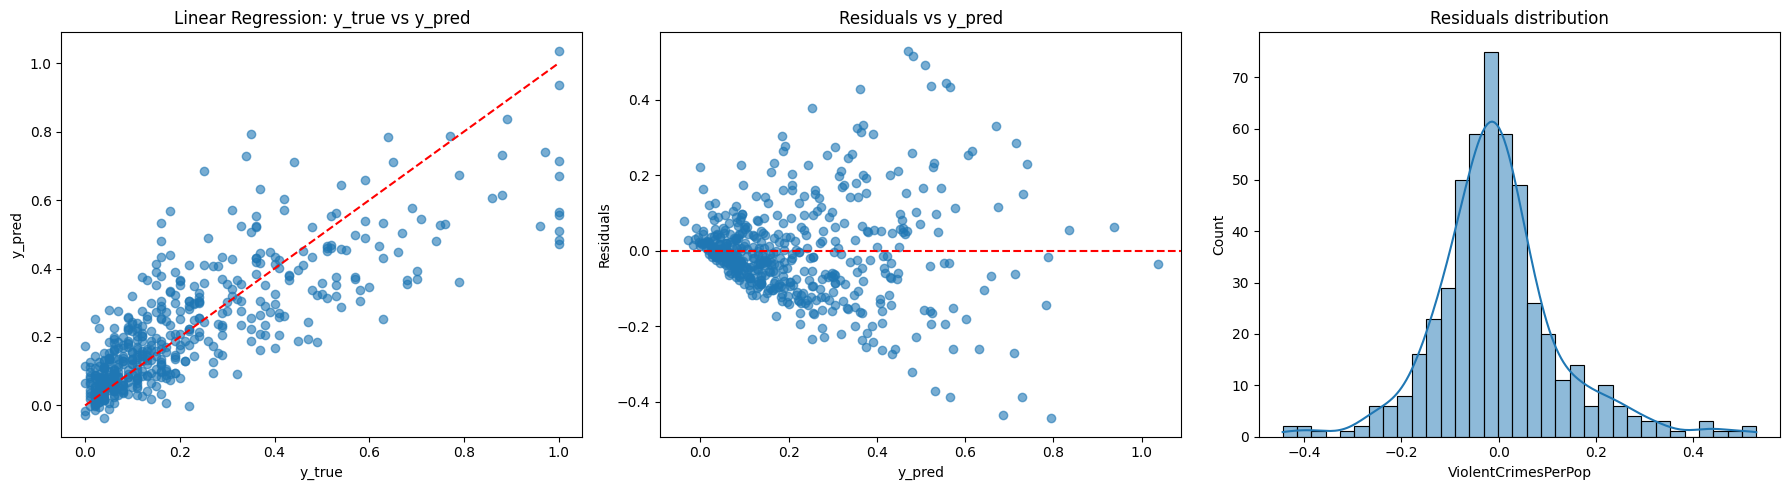

In [ ]:
y_pred_lr = lin_reg.predict(X_test)
residuals_lr = y_test - y_pred_lr

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_lr, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--')
axes[0].set_title("Linear Regression: y_true vs y_pred")
axes[0].set_xlabel("y_true")
axes[0].set_ylabel("y_pred")

axes[1].scatter(y_pred_lr, residuals_lr, alpha=0.6)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_title("Residuals vs y_pred")
axes[1].set_xlabel("y_pred")
axes[1].set_ylabel("Residuals")

sns.histplot(residuals_lr, kde=True, ax=axes[2])
axes[2].set_title("Residuals distribution")

plt.tight_layout()
plt.show()


In [ ]:
#lasso

pipeline_lasso = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.1))
])

pipeline_lasso.fit(X_train, y_train)
y_pred_lasso = pipeline_lasso.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"MAE: {mae_lasso:.4f}")
print(f"R2 Score: {r2_lasso:.4f}")
print(f"RMSE: {rmse_lasso:.4f}")
print(f"MSE: {mse_lasso:.4f}")


MAE: 0.1330
R2 Score: 0.3990
RMSE: 0.1709
MSE: 0.0292


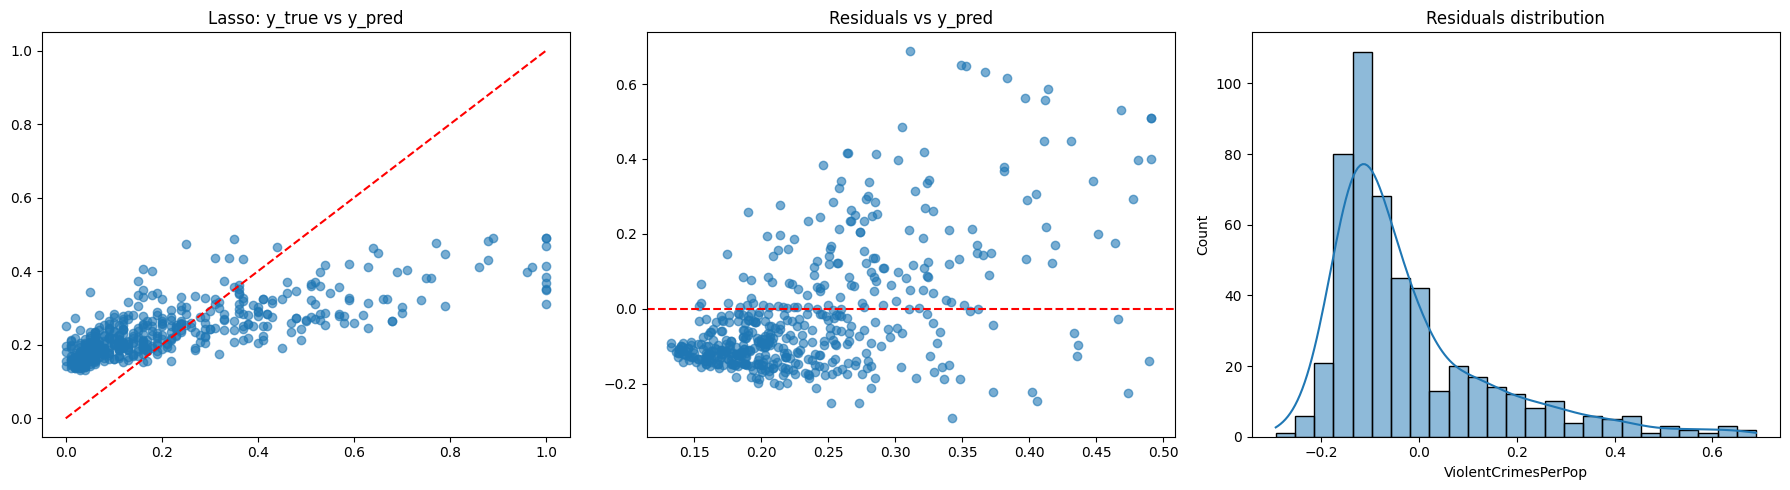

In [ ]:
y_pred_lasso = pipeline_lasso.predict(X_test)
residuals_lasso = y_test - y_pred_lasso

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_lasso, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--')
axes[0].set_title("Lasso: y_true vs y_pred")

axes[1].scatter(y_pred_lasso, residuals_lasso, alpha=0.6)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_title("Residuals vs y_pred")

sns.histplot(residuals_lasso, kde=True, ax=axes[2])
axes[2].set_title("Residuals distribution")

plt.tight_layout()
plt.show()


In [ ]:
#ridge


pipeline_ridge = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=0.1))
])

pipeline_ridge.fit(X_train, y_train)

y_pred_ridge = pipeline_ridge.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"MAE: {mae_ridge:.4f}")
print(f"R2 Score: {r2_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.4f}")
print(f"MSE: {mse_ridge:.4f}")


MAE: 0.0912
R2 Score: 0.6545
RMSE: 0.1296
MSE: 0.0168


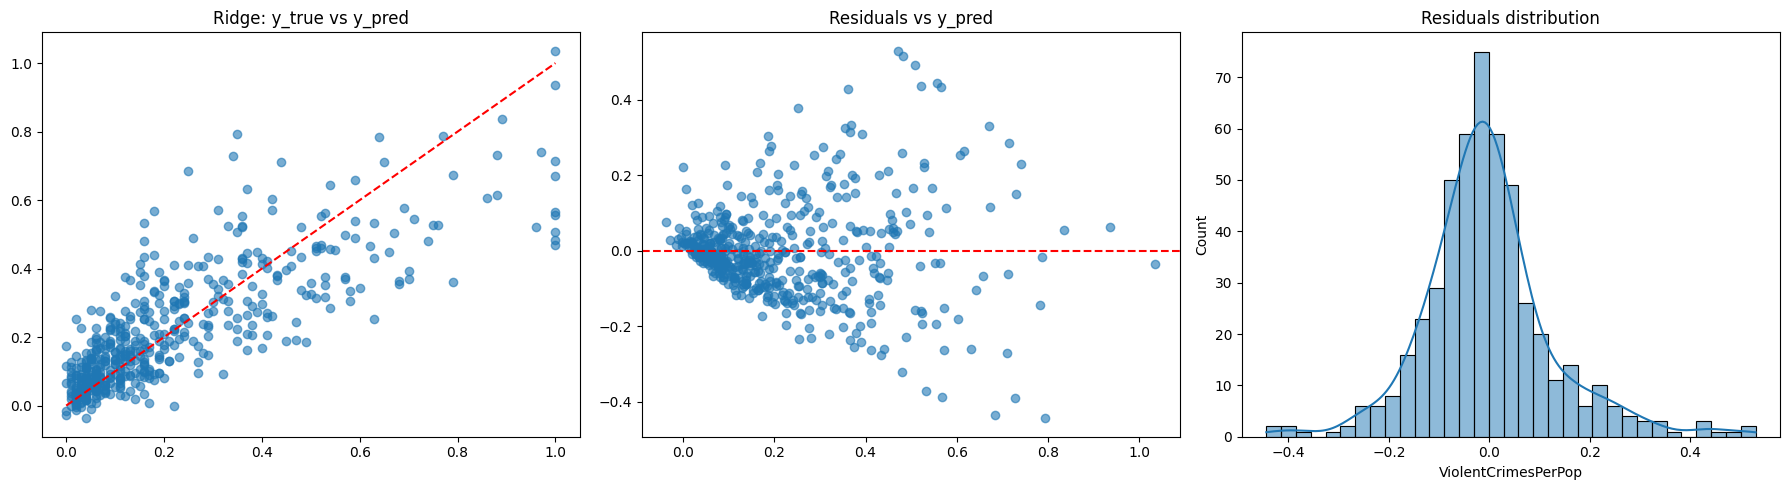

In [ ]:
y_pred_ridge = pipeline_ridge.predict(X_test)
residuals_ridge = y_test - y_pred_ridge

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_ridge, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--')
axes[0].set_title("Ridge: y_true vs y_pred")

axes[1].scatter(y_pred_ridge, residuals_ridge, alpha=0.6)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_title("Residuals vs y_pred")

sns.histplot(residuals_ridge, kde=True, ax=axes[2])
axes[2].set_title("Residuals distribution")

plt.tight_layout()
plt.show()


# Regresja nieliniowa

In [ ]:
#regresja wielomianowa ^2


pipeline_poly = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])

pipeline_poly.fit(X_train, y_train)
y_pred_poly = pipeline_poly.predict(X_test)

mse_poly2 = mean_squared_error(y_test, y_pred_poly)
rmse_poly2 = np.sqrt(mse_poly2)
mae_poly2 = mean_absolute_error(y_test, y_pred_poly)
r2_poly2 = r2_score(y_test, y_pred_poly)

print('R2: ' + str(r2_poly2))
print('MSE: ' + str(mse_poly2))
print('RMSE: ' + str(rmse_poly2))
print('MAE: ' + str(mae_poly2))



R2: 0.5335289214640065
MSE: 0.02268183092989402
RMSE: 0.15060488348620713
MAE: 0.10497189777815447


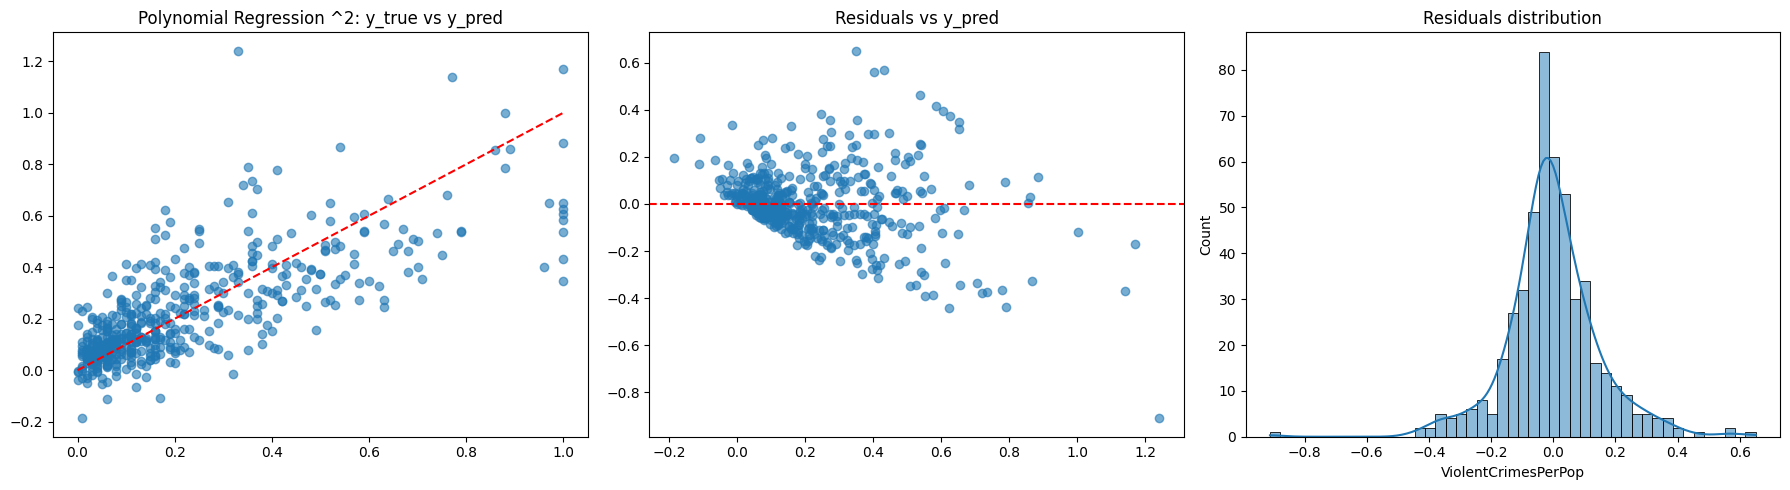

In [ ]:
y_pred_poly = pipeline_poly.predict(X_test)
residuals_poly = y_test - y_pred_poly

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_poly, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--')
axes[0].set_title("Polynomial Regression ^2: y_true vs y_pred")

axes[1].scatter(y_pred_poly, residuals_poly, alpha=0.6)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_title("Residuals vs y_pred")

sns.histplot(residuals_poly, kde=True, ax=axes[2])
axes[2].set_title("Residuals distribution")

plt.tight_layout()
plt.show()


In [ ]:
#regresja wielomianowa ^3


pipeline_poly = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('model', LinearRegression())
])

pipeline_poly.fit(X_train, y_train)
y_pred_poly = pipeline_poly.predict(X_test)

mse_poly3 = mean_squared_error(y_test, y_pred_poly)
rmse_poly3 = np.sqrt(mse_poly3)
mae_poly3 = mean_absolute_error(y_test, y_pred_poly)
r2_poly3 = r2_score(y_test, y_pred_poly)

print('R2: ' + str(r2_poly3))
print('MSE: ' + str(mse_poly3))
print('RMSE: ' + str(rmse_poly3))
print('MAE: ' + str(mae_poly3))



R2: -29.70945848711596
MSE: 1.4932260056496018
RMSE: 1.221976270493663
MAE: 0.5821901089850773


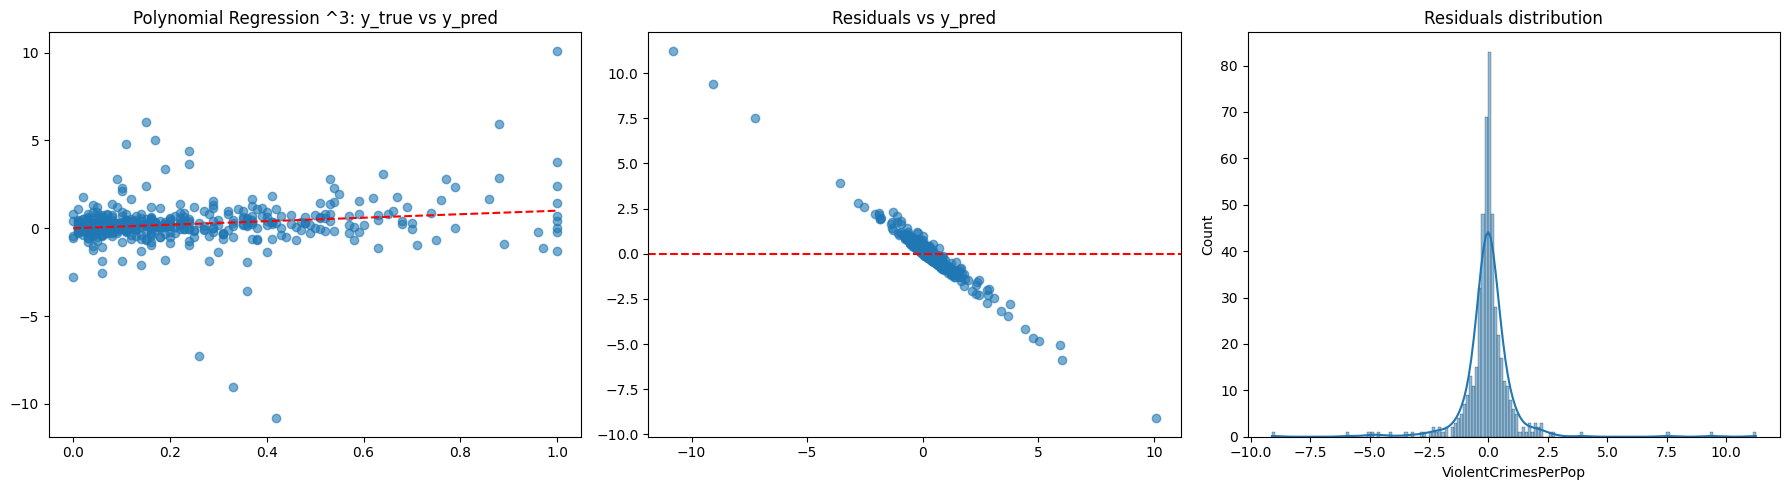

In [ ]:
y_pred_poly = pipeline_poly.predict(X_test)
residuals_poly = y_test - y_pred_poly

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_poly, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--')
axes[0].set_title("Polynomial Regression ^3: y_true vs y_pred")

axes[1].scatter(y_pred_poly, residuals_poly, alpha=0.6)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_title("Residuals vs y_pred")

sns.histplot(residuals_poly, kde=True, ax=axes[2])
axes[2].set_title("Residuals distribution")

plt.tight_layout()
plt.show()


# Random forest drzew regresyjnych

In [ ]:
rf = RandomForestRegressor(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

grid_search_rf = GridSearchCV(estimator=rf,
                               param_grid=param_grid_rf,
                               cv=3,
                               scoring='r2',
                               n_jobs=-1)

grid_search_rf.fit(X_train, y_train)

print("Najlepsze parametry RF:", grid_search_rf.best_params_)

best_rf = grid_search_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MSE: {mse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R^2: {r2_rf:.4f}")

Najlepsze parametry RF: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
MSE: 0.0174
MAE: 0.0936
RMSE: 0.1320
R^2: 0.6416


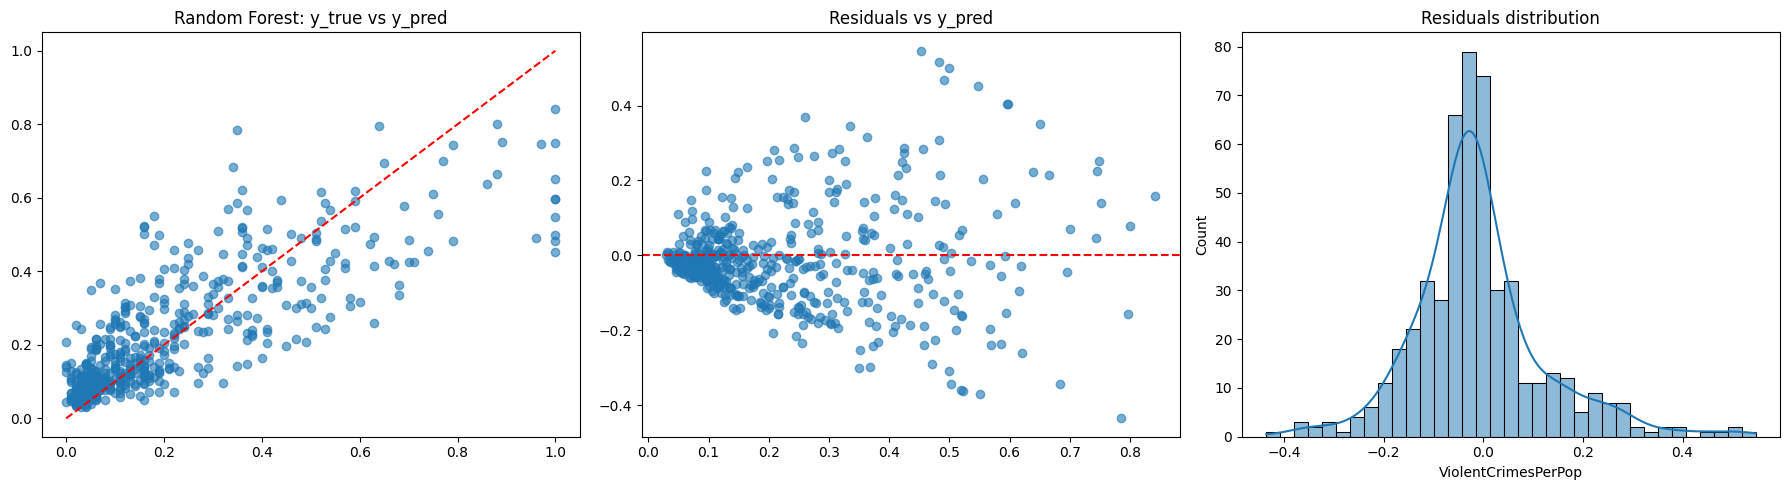

In [ ]:
y_pred_rf = best_rf.predict(X_test)
residuals_rf = y_test - y_pred_rf

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_rf, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--')
axes[0].set_title("Random Forest: y_true vs y_pred")

axes[1].scatter(y_pred_rf, residuals_rf, alpha=0.6)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_title("Residuals vs y_pred")

sns.histplot(residuals_rf, kde=True, ax=axes[2])
axes[2].set_title("Residuals distribution")

plt.tight_layout()
plt.show()


# Sieć neuronowa


===== WYNIKI (TEST) =====
MSE: 0.017917
MAE: 0.096050
RMSE: 0.133854
R^2: 0.631522


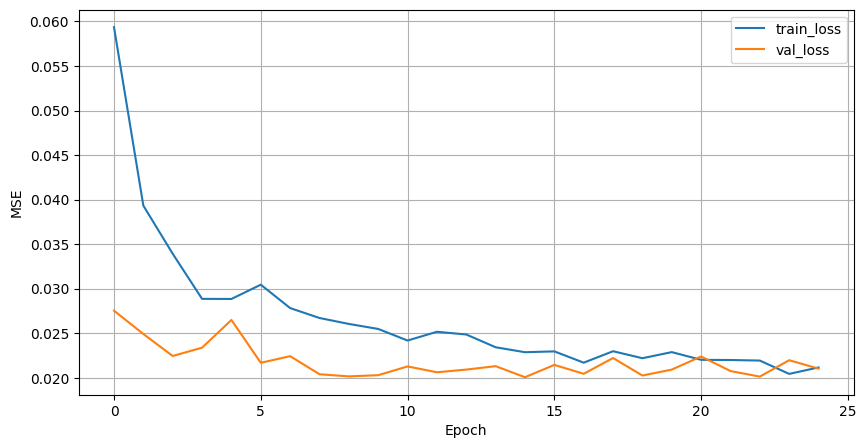

In [ ]:
#Sieć neuronowa
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1)  # regresja
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

#model.summary() # tabelka


#Trenowanie z EarlyStopping
early = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early],
    verbose=0
)


#Ewaluacja
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

y_pred = model.predict(X_test, verbose=0).ravel()

mse_nn = mean_squared_error(y_test, y_pred)
mae_nn = mean_absolute_error(y_test, y_pred)
r2_nn = r2_score(y_test, y_pred)
rmse_nn = np.sqrt(mse_nn)

print("\n===== WYNIKI (TEST) =====")
print(f"MSE: {mse_nn:.6f}")
print(f"MAE: {mae_nn:.6f}")
print(f"RMSE: {rmse_nn:.6f}")
print(f"R^2: {r2_nn:.6f}")


#Wykres uczenia

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()

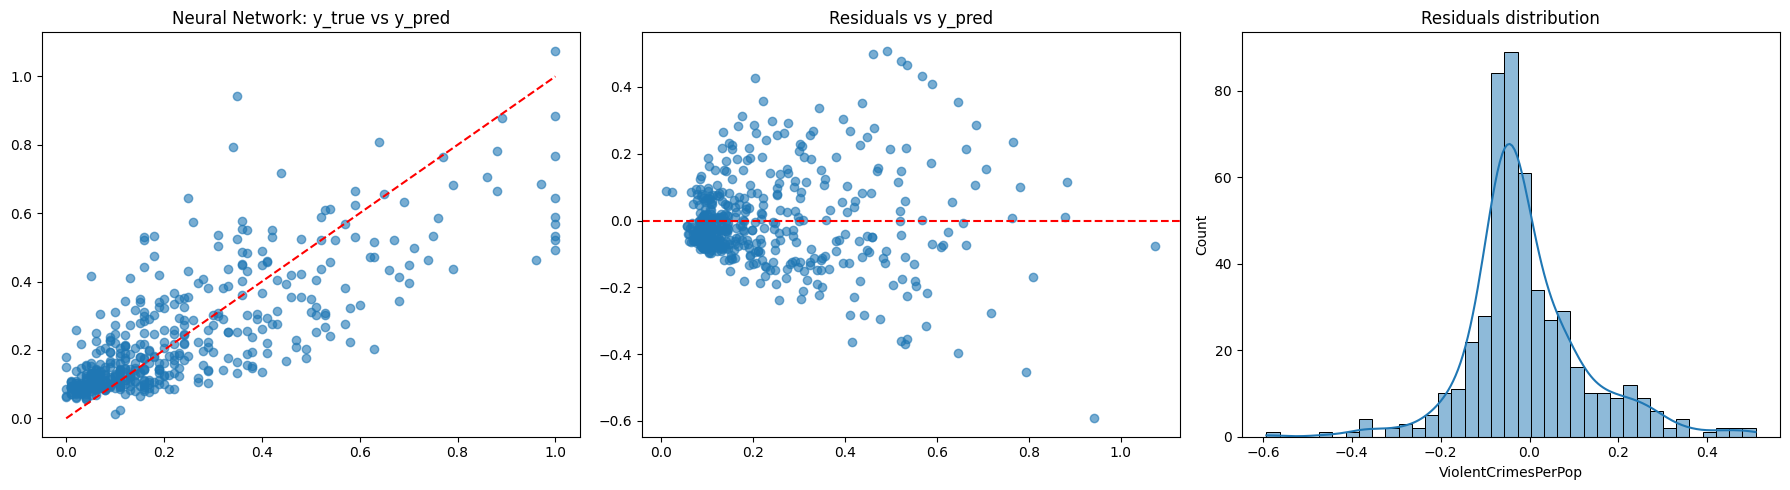

In [ ]:
y_pred_nn = model.predict(X_test, verbose=0).ravel()
residuals_nn = y_test - y_pred_nn

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_nn, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--')
axes[0].set_title("Neural Network: y_true vs y_pred")

axes[1].scatter(y_pred_nn, residuals_nn, alpha=0.6)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_title("Residuals vs y_pred")

sns.histplot(residuals_nn, kde=True, ax=axes[2])
axes[2].set_title("Residuals distribution")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

min_metrics = ["MSE", "RMSE", "MAE"]

def highlight_best_worst(row):
    if row.name in min_metrics:
        best = row.min()
        worst = row.max()
    else:  # R2
        best = row.max()
        worst = row.min()

    styles = []
    for val in row:
        if val == best:
            styles.append("background-color: rgba(99, 255, 99, 0.5)")
        elif val == worst:
            styles.append("background-color: rgba(255, 99, 99, 0.5)")
        else:
            styles.append("")
    return styles

df = pd.DataFrame({
    "Model": ["Linear", "Lasso", "Ridge", "Polynomial ^2", "Polynomial ^3", "Random forest", "Neural network"],
    "MSE": [mse_lr, mse_lasso, mse_ridge, mse_poly2, mse_poly3, mse_rf, mse_nn],
    "RMSE": [rmse_lr, rmse_lasso, rmse_ridge, rmse_poly2, rmse_poly3, rmse_rf, rmse_nn],
    "MAE": [mae_lr, mae_lasso, mae_ridge, mae_poly2, mae_poly3, mae_rf, mae_nn],
    "R2": [r2_lr, r2_lasso, r2_ridge, r2_poly2, r2_poly3, r2_rf, r2_nn]
})

df_transposed = df.set_index("Model").T

df_transposed.style.apply(highlight_best_worst, axis=1).format("{:.4f}")


Model,Linear,Lasso,Ridge,Polynomial ^2,Polynomial ^3,Random forest,Neural network
MSE,0.0168,0.0292,0.0168,0.0227,1.4932,0.0174,0.0179
RMSE,0.1296,0.1709,0.1296,0.1506,1.2220,0.1320,0.1339
MAE,0.0912,0.1330,0.0912,0.1050,0.5822,0.0936,0.0960
R2,0.6545,0.3990,0.6545,0.5335,-29.7095,0.6416,0.6315
